# Imagery and annotations

<!-- markdownlint-disable MD033-->
<div class="page-subtitle">
Checking whether source imagery and labels actually match
</div>
<!-- markdownlint-enable MD033 -->

---

## 1. Motivation

Every problem that starts here, a CRS mismatch, a label that only partly covers the image, an unexpected image artifact, gets multiplied once you tile the data into hundreds of chips. Catching it now, on one image, is far cheaper than catching it later, across a whole batch.

This stage is also where {term}`annotation <Annotation>` quality is set. An annotation can be a polygon, line, point, bounding box, mask or class label. For many GeoAI projects, annotations define what the model should learn. Annotations are usually created by a person who has looked carefully at the imagery, sometimes called "human-in-the-loop" labeling, and their quality depends directly on how carefully that labeling was done and checked.

---

## 2. Core idea

Before creating training data, visually check the relationship between the image and the labels.

For a building-mapping example, the basic question is:

```text
Do the building polygons align with the rooftops visible in the imagery?
```

For other projects, the same logic applies:

```text
Do my reference labels match the image content, date, location and scale?
```

This step is simple, but it can prevent many modelling problems later.

---

## 3. Workflow

### A. Download sample datasets

The sample workflow uses {term}`NAIP` imagery and building footprint polygons.

In [18]:
from pathlib import Path

import geoai

DATA_DIR = Path("data/raw")
DATA_DIR.mkdir(parents=True, exist_ok=True)

raster_url = "https://data.source.coop/giuz/sds320/L04/data/willisau_2024_swissimage_rgb_subset_05m.tif"
vector_url = "https://data.source.coop/giuz/sds320/L04/data/willisau_2024_swissbuildings3D_clip.geojson"

raster_path = geoai.download_file(
    raster_url, output_path=str(DATA_DIR / Path(raster_url).name)
)
vector_path = geoai.download_file(
    vector_url, output_path=str(DATA_DIR / Path(vector_url).name)
)

The raster is the source image. The vector file contains building polygons digitised for the same area.

### B. Preview the source imagery

Start with the image alone. Check whether the area, resolution and visual quality fit the task.

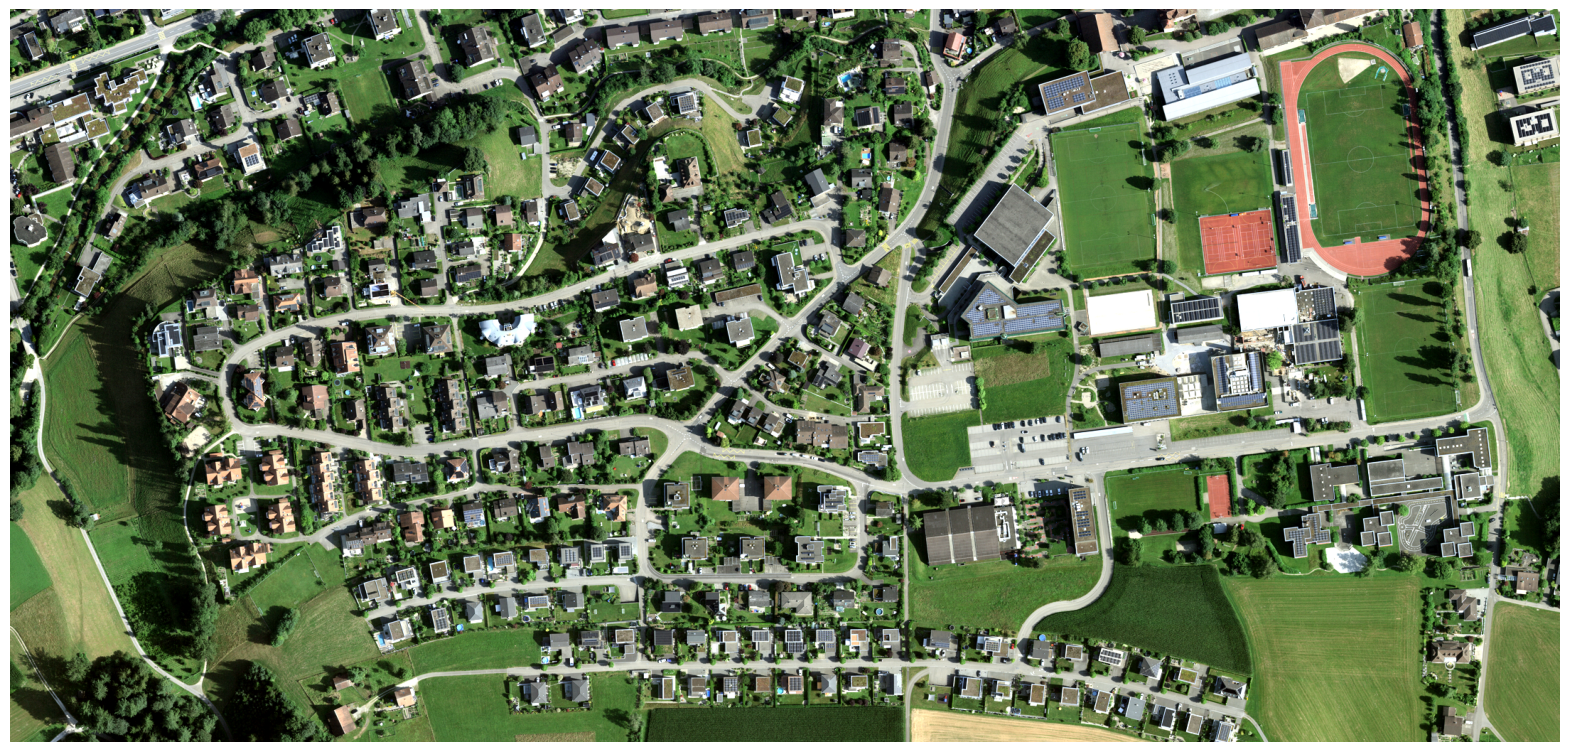

In [19]:
geoai.view_image(raster_path, figsize=(20, 10))

Look for obvious problems:

- clouds or haze,
- strong shadows,
- missing areas,
- blurred imagery,
- objects that are too small to see,
- unexpected land-cover patterns.

### C. Overlay annotations on imagery

Now compare the vector labels with the image.

<Axes: >

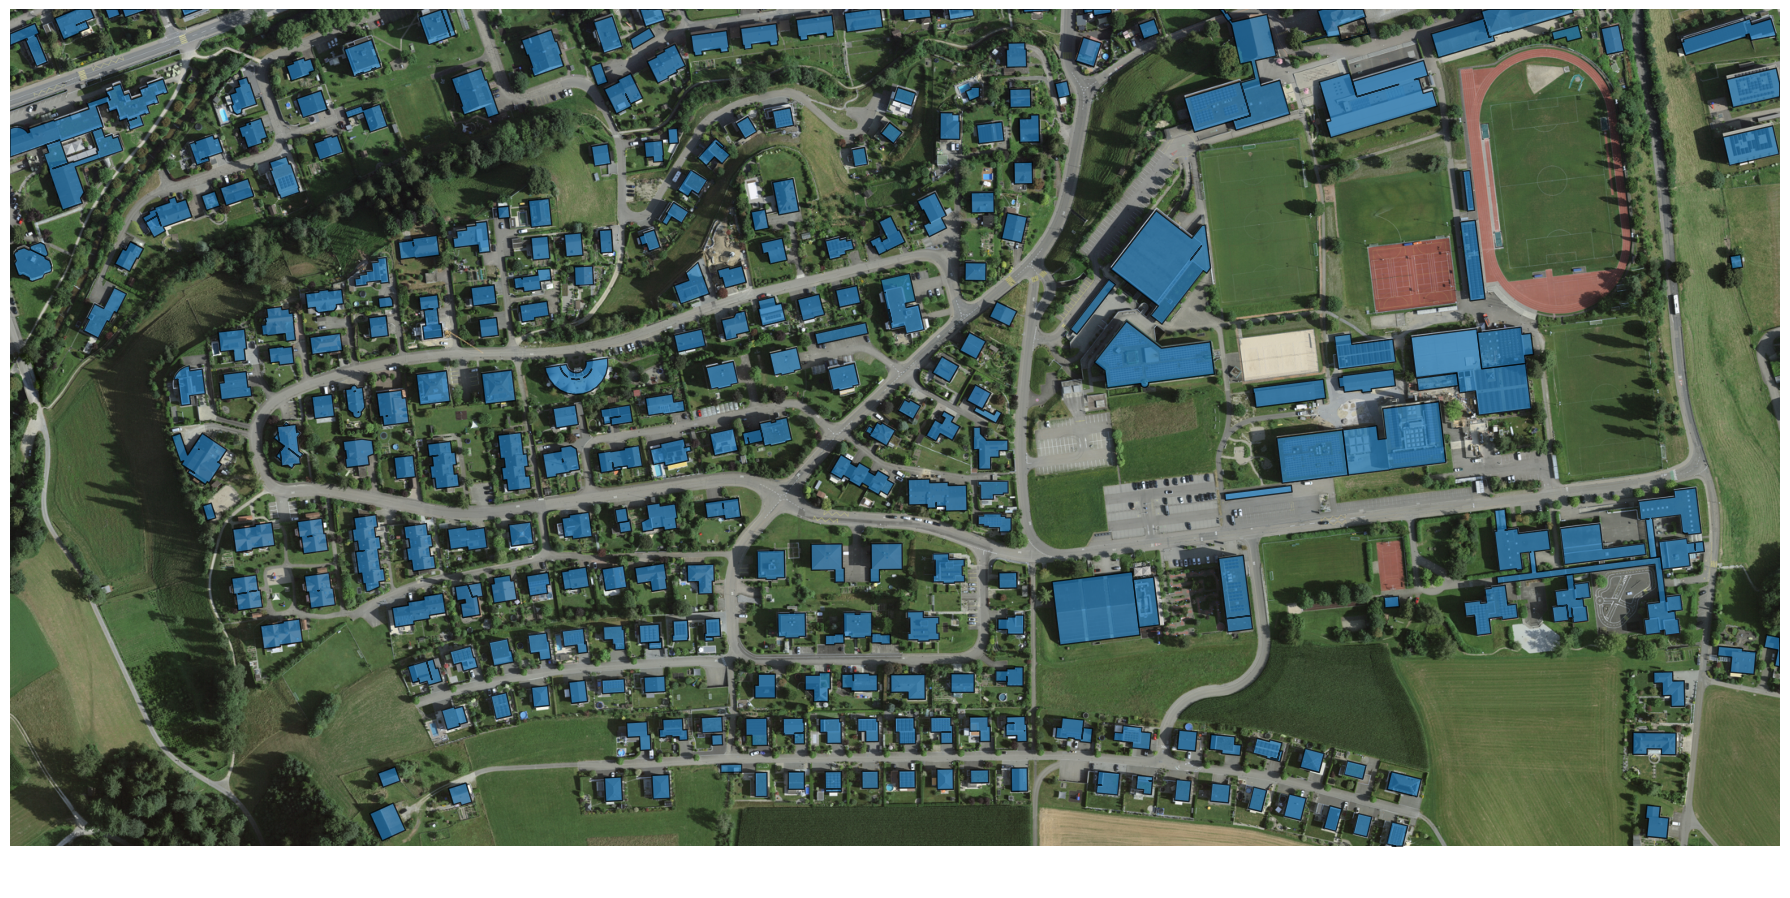

In [20]:
geoai.view_vector(vector_path, raster_path=raster_path, figsize=(18, 10))

The source chapter shows this as building footprints drawn on top of the NAIP image. Use the same idea in your project: the label should point to the same feature that is visible in the source imagery.

### D. Inspect interactively

Static figures are useful, but interactive maps make it easier to zoom into specific problems.

In [21]:
import geopandas as gpd

# The swissBUILDINGS3D export has datetime columns (DATUM_ERSTELLUNG,
# DATUM_AENDERUNG). folium/leafmap can't serialize pandas Timestamp values
# to JSON when building the interactive popup, so convert them to strings
# before mapping.
vector_gdf = gpd.read_file(vector_path)
for col in vector_gdf.columns:
    if vector_gdf[col].dtype.kind == "M":  # datetime64, incl. timezone-aware
        vector_gdf[col] = vector_gdf[col].astype(str)

geoai.view_vector_interactive(vector_gdf, tiles=raster_path)

Zoom into several locations. Check both easy and difficult areas, including dense buildings, shadows, image edges and small structures.

### E. Check CRS, bounds and overlap

At this stage, check three things explicitly:

1. Do the annotation polygons sit on top of the features they describe?
2. Do the annotations cover the image extent, only part of it, or more than it?
3. Does the imagery itself look usable for the target feature?

In [22]:
import geopandas as gpd
import rasterio
from shapely.geometry import box

gdf = gpd.read_file(vector_path)

with rasterio.open(raster_path) as src:
    raster_crs = src.crs
    raster_bounds = src.bounds
    raster_extent = box(*raster_bounds)

print("Raster CRS:", raster_crs)
print("Vector CRS:", gdf.crs)
print("Raster bounds:", raster_bounds)
print("Vector bounds:", gdf.total_bounds)

Raster CRS: EPSG:2056
Vector CRS: EPSG:2056
Raster bounds: BoundingBox(left=2641062.19, bottom=1218339.81, right=2642152.69, top=1218855.31)
Vector bounds: [2641062.19 1218339.71 2642152.49 1218855.31]


If the CRS differs, reproject the vector layer for inspection before deciding whether the data are usable.

In [23]:
if gdf.crs != raster_crs:
    gdf = gdf.to_crs(raster_crs)

gdf_extent = box(*gdf.total_bounds)

print("Annotations overlap image:", gdf_extent.intersects(raster_extent))
print("Annotations fully inside image:", raster_extent.contains(gdf_extent))

Annotations overlap image: True
Annotations fully inside image: False


This check does not replace visual inspection. It helps you understand whether a visual problem is caused by CRS, extent or label quality.

### F. Decide how to treat mismatches

Use this table before continuing to raster masks or tiling.

| Situation | What happens if you ignore it | What to do |
| --- | --- | --- |
| Annotations are far away from the imagery | Tiling may still run, but labels become meaningless. | Check CRS first. If the CRS is missing or wrongly assigned, fix the metadata only if you are certain. If the CRS is different, reproject. If the layer is still far away, do not use it. |
| Annotations are slightly shifted everywhere | The model learns shifted boundaries and may perform poorly even if training loss looks acceptable. | Check whether the shift is constant. Compare several control points. Use an aligned label source if possible. Only apply a manual shift if you can justify and document it. |
| Shift varies across the image | The problem is likely not a simple CRS issue. It may come from georeferencing, orthorectification, digitising quality or date mismatch. | Do not fix this with a single translation. Use better aligned data, relabel the area, or reduce the project scope. |
| Some annotations exceed the image extent | Rasterisation clips labels to the reference raster extent. Outside parts disappear silently. | Clip annotations to the raster extent before rasterisation, or filter to features fully inside the image. Document the choice. |
| The image cuts through a house, but the vector polygon contains the full house | The mask will contain only the visible part inside the raster. For segmentation this may be acceptable; for object detection or instance segmentation it may create confusing partial objects. | For segmentation, clipped masks can be fine if you train the model to predict visible pixels. For object-level tasks, consider removing edge-touching objects, using a larger image extent, or using overlap so the object appears fully in another chip. |
| Annotation coverage is smaller than the imagery | Unlabelled parts of the image may be interpreted as background, even though they were simply never annotated. | Restrict training to the labelled area, create a labelled-area mask, or drop tiles outside the annotation coverage. Do not treat unlabelled areas as true background. |
| Some visible objects are missing from the annotations | The model learns that those objects are background. | Add missing labels, choose a better label source, or exclude affected areas from training. |
| Annotation date differs from imagery date | Real changes may look like label errors. | Check acquisition dates. Use matching dates where possible, or document the mismatch and avoid areas with obvious change. |

```{admonition} Catch it here, not after tiling
:class: important

A CRS mismatch or misaligned annotation is usually obvious in a single overlay. Once you have generated hundreds of tiles from the same data, the same problem appears as noisy training data and a hard-to-diagnose drop in model performance.
```

### G. Clip or filter annotations if needed

If annotations extend beyond the image, decide whether to clip them or keep only features fully inside the raster.

Clipping is reasonable when your model should learn only the visible part of a feature inside the image.

In [24]:
gdf_clipped = gpd.clip(gdf, raster_extent)
print("Original features:", len(gdf))
print("Clipped features:", len(gdf_clipped))

Original features: 277
Clipped features: 277


Filtering to fully contained features is stricter. It is useful when partial objects would confuse the task.

In [25]:
inside = gdf.geometry.within(raster_extent)
gdf_inside = gdf.loc[inside].copy()

print("Features fully inside image:", len(gdf_inside))
print("Features touching or crossing image boundary:", len(gdf) - len(gdf_inside))

Features fully inside image: 276
Features touching or crossing image boundary: 1


For building footprints, both choices can be reasonable depending on the task:

- **Semantic segmentation:** clipping boundary polygons is often acceptable because the target is “building pixels visible in the image”.
- **Object detection:** partial objects can produce boxes that describe only part of an object, so edge objects may need to be removed.
- **Instance segmentation:** partial objects can affect object counts and shape metrics, so removing edge-touching instances is often safer.
- **Change detection:** date mismatch may matter more than clipping, because the feature may genuinely have changed.

Document the choice before generating masks or chips.

---

## 4. Common pitfalls

- **Assuming a downloaded annotation file automatically matches the image's extent.** Some annotation files cover a smaller or larger area than the image; check this visually rather than assuming it.
- **Skipping the interactive view because the static one "looked fine."** Static previews at a small figure size can hide small misalignments that are obvious once you zoom in.
- **Not checking the CRS explicitly.** Two files can visually appear to line up in a preview and still have subtly different CRSs; if in doubt, check `raster.crs` and `gdf.crs` directly, as you did in SDS210.

---

## 5. Key takeaways

- Training labels should be visually checked before conversion.
- Overlaying annotations on imagery helps detect misalignment and missing labels.
- Interactive inspection is better than checking only one static overview.
- Label quality problems become model problems later.
- Do not create chips until the source imagery and annotations are plausible.

### Useful links

- [GeoAI Video Tutorial](https://youtu.be/QqjhLFN8Hdc?si=B38bNd_YpeSwt4nE) - create a labeled dataset for deep learning